In [307]:
import pandas as pd
import optuna
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
# from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from datetime import datetime

from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task
from lightautoml.automl.blend import WeightedBlender

In [31]:
train_df = pd.read_csv('train_apps.csv')
test_df = pd.read_csv('test_apps.csv')

In [103]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145241 entries, 0 to 145240
Data columns (total 42 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   loan_amount_last                        145241 non-null  float64
 1   overdraft_limit_min                     145241 non-null  float64
 2   overdraft_limit_max                     145241 non-null  float64
 3   offered_rate                            145241 non-null  float64
 4   cb_rate                                 145241 non-null  float64
 5   corp_credit_products                    145241 non-null  float64
 6   sum_deb_ul_90                           145241 non-null  float64
 7   sum_deb_ul_30                           145241 non-null  float64
 8   cnt_deb_loan_90                         145241 non-null  float64
 9   cnt_deb_ul_ip_90                        145241 non-null  float64
 10  cnt_deb_ul_ip_30                        1452

In [36]:
(train_df[train_df['target_value'] == 1].isna().sum() / len(train_df[train_df['target_value'] == 1]) * 100)

front_id                              0.000000
decision_day                          0.000000
loan_amount_last                      0.000000
overdraft_limit_min                   0.000000
overdraft_limit_max                   0.000000
offered_rate                          0.000000
cb_rate                               0.000000
corp_credit_products                 12.740222
sum_deb_ul_90                        12.050644
sum_deb_ul_30                        14.560253
cnt_deb_loan_90                       6.771422
cnt_deb_ul_ip_90                      6.070540
cnt_deb_ul_ip_30                      6.884468
balance_rur_amt_30_min               10.558444
cnt_cred_loan_90                      6.771422
loan_rev_max_start_non_fin           70.947321
loan_rev_min_start_fin               61.847163
app_term_mean_360                    33.156229
overdraft_app_term_max_360           80.748361
days_from_authperson_registration    31.121411
fl_hdb_bki_total_active_products     11.711508
corp_list    

In [38]:
(train_df[train_df['target_value'] == 0].isna().sum() / len(train_df[train_df['target_value'] == 0]) * 100)

front_id                              0.000000
decision_day                          0.000000
loan_amount_last                      0.000000
overdraft_limit_min                   0.000000
overdraft_limit_max                   0.000000
offered_rate                          0.000000
cb_rate                               0.000000
corp_credit_products                 36.702958
sum_deb_ul_90                        38.890722
sum_deb_ul_30                        44.110855
cnt_deb_loan_90                      22.624730
cnt_deb_ul_ip_90                     21.824847
cnt_deb_ul_ip_30                     24.021408
balance_rur_amt_30_min               24.848418
cnt_cred_loan_90                     22.624730
loan_rev_max_start_non_fin           92.641959
loan_rev_min_start_fin               87.418894
app_term_mean_360                    38.821071
overdraft_app_term_max_360           97.209575
days_from_authperson_registration    55.515231
fl_hdb_bki_total_active_products     17.106199
corp_list    

### ISNA

In [33]:
is_na_cols = train_df.columns[7:-1]
is_na_cols

Index(['corp_credit_products', 'sum_deb_ul_90', 'sum_deb_ul_30',
       'cnt_deb_loan_90', 'cnt_deb_ul_ip_90', 'cnt_deb_ul_ip_30',
       'balance_rur_amt_30_min', 'cnt_cred_loan_90',
       'loan_rev_max_start_non_fin', 'loan_rev_min_start_fin',
       'app_term_mean_360', 'overdraft_app_term_max_360',
       'days_from_authperson_registration', 'fl_hdb_bki_total_active_products',
       'corp_list', 'count_all_corp_dashboard_events',
       'p75_time_spent_minutes', 'sum_deb_investment_90', 'db_group_last',
       'fl_adminarea'],
      dtype='object')

In [35]:
isna_train = train_df[is_na_cols].isna().astype(int)
isna_train.columns = list(map(lambda x: x + '_isna', isna_train.columns))

isna_test = test_df[is_na_cols].isna().astype(int)
isna_test.columns = list(map(lambda x: x + '_isna', isna_test.columns))

In [37]:
train_df = pd.concat([train_df, isna_train], axis = 1)
test_df = pd.concat([test_df, isna_test], axis = 1)

### Coding fl_adminarea

In [39]:
class RareCategoryHandler:
    def __init__(self, min_count=100):
        self.min_count = min_count
        self.rare_maps = {}
    
    
    def fit(self, df, columns):
        for col in columns:
            value_counts = df[col].dropna().value_counts()
            rare_values = value_counts[value_counts < self.min_count].index.tolist()
            self.rare_maps[col] = set(rare_values)
        return self
    
    def transform(self, df):
        df_transformed = df.copy()
        for col in self.rare_maps.keys():
            if col in df_transformed.columns:
                rare_set = self.rare_maps[col]
                df_transformed[col] = df_transformed[col].apply(
                    lambda x: 'other' if pd.notna(x) and x in rare_set else x
                )
                df_transformed[col] = df_transformed[col].fillna('unknown')
        return df_transformed

In [41]:
handler = RareCategoryHandler(min_count=50)
handler.fit(train_df, ['fl_adminarea'])

In [43]:
train_df = handler.transform(train_df)
test_df = handler.transform(test_df)

In [47]:
# df_encoded = train_df[['fl_adminarea']].copy()
# df_encoded_t = test_df[['fl_adminarea']].copy()
# freq_map = train_df['fl_adminarea'].value_counts(normalize=True).to_dict()

In [49]:
# df_encoded[f"{'fl_adminarea'}_freq"] = train_df['fl_adminarea'].map(freq_map) * 6
# train_df['fl_adminarea'] = df_encoded['fl_adminarea_freq']

# df_encoded_t[f"{'fl_adminarea'}_freq"] = test_df['fl_adminarea'].map(freq_map) * 6
# test_df['fl_adminarea'] = df_encoded_t['fl_adminarea_freq']

### Droping

In [55]:
# na_cols = []
# for col in train_df:
#     if train_df[col].isna().sum() > 80000:
#         na_cols.append(col)

In [57]:
# na_cols

['loan_rev_max_start_non_fin',
 'loan_rev_min_start_fin',
 'overdraft_app_term_max_360',
 'sum_deb_investment_90']

In [59]:
# train_df = train_df.drop(na_cols, axis=1)
# test_df = test_df.drop(na_cols, axis=1)

In [61]:
# train_df = train_df.drop(['decision_day'], axis=1)
# train_df = train_df.drop(['front_id'], axis=1)
# test_df = test_df.drop(['decision_day','front_id'], axis=1)

### Filling

In [45]:
train_df['db_group_last'] = train_df['db_group_last'].fillna('unknown')
test_df['db_group_last'] = test_df['db_group_last'].fillna('unknown')

In [107]:
categorical_features = ['db_group_last','fl_adminarea']

In [105]:
train_df['db_group_last'] = train_df['db_group_last'].astype('category')
test_df['db_group_last'] = test_df['db_group_last'].astype('category')

train_df['fl_adminarea'] = train_df['fl_adminarea'].astype('category')
test_df['fl_adminarea'] = test_df['fl_adminarea'].astype('category')

In [65]:
# train_df.fillna(train_df.min(), inplace=True)
# test_df.fillna(test_df.min(), inplace=True)

### Data split

In [48]:
train_df['decision_day'] = pd.to_datetime(train_df['decision_day'])
train_df = train_df.sort_values('decision_day').reset_index(drop=True)

test_df['decision_day'] = pd.to_datetime(test_df['decision_day'])

In [52]:
# 2. Извлечение признаков
train_df['day_of_week'] = train_df['decision_day'].dt.dayofweek
train_df['month'] = train_df['decision_day'].dt.month
train_df['quarter'] = train_df['decision_day'].dt.quarter
train_df['year'] = train_df['decision_day'].dt.year
train_df['is_weekend'] = (train_df['day_of_week'] >= 5).astype(int)

test_df['day_of_week'] = test_df['decision_day'].dt.dayofweek
test_df['month'] = test_df['decision_day'].dt.month
test_df['quarter'] = test_df['decision_day'].dt.quarter
test_df['year'] = test_df['decision_day'].dt.year
test_df['is_weekend'] = (test_df['day_of_week'] >= 5).astype(int)

In [54]:
features = [c for c in train_df.columns
            if c not in ['target_value', 'front_id', 'decision_day']]
X_train = train_df[features]
y_train = train_df['target_value']

In [56]:
X_test = test_df[features]

In [248]:
def time_series_cv_split(X, y, date_col, n_splits=5):
    dates = X[date_col]
    unique_dates = sorted(dates.unique())
    n_dates = len(unique_dates)
    fold_size = n_dates // (n_splits + 1)

    splits = []
    for i in range(n_splits):
        val_start_idx = n_dates - (i + 1) * fold_size
        if val_start_idx < 0:
            val_start_idx = 0

        val_start_date = unique_dates[val_start_idx]
        val_end_date = unique_dates[-1] if i == 0 else unique_dates[n_dates - i * fold_size - 1]
        #print(val_start_date, val_end_date)
        train_mask = dates < val_start_date
        val_mask = (dates >= val_start_date) & (dates <= val_end_date)
        #print(val_mask)

        X_train_fold = X[train_mask]
        y_train_fold = y[train_mask]
        X_val_fold = X[val_mask]
        y_val_fold = y[val_mask]

        splits.append((X_train_fold, X_val_fold, y_train_fold, y_val_fold))
    return splits

In [259]:
#time_series_cv_split(train_df, y_train, 'decision_day', n_splits=5)[4][3]

### Optuna

In [273]:
def objective_lgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        #'max_depth': trial.suggest_int('max_depth', 4, 8),
        'num_leaves': trial.suggest_int('num_leaves', 13, 31),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 100),
        'lambda_l2': trial.suggest_float('lambda_l2', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'num_threads': 16,
        'is_unbalance': True,
        'early_stopping_rounds':100,
        'verbose': 0
    }

    splits = time_series_cv_split(train_df, y_train, 'decision_day', n_splits=5)
    auc_scores = []

    for X_train_fold, X_val_fold, y_train_fold, y_val_fold in splits:
        train_data = lgb.Dataset(
            X_train_fold[features],
            label=y_train_fold,
            categorical_feature=categorical_features 
        )
        val_data = lgb.Dataset(
            X_val_fold[features],
            label=y_val_fold,
            categorical_feature=categorical_features
        )
        model = lgb.train(
            params,
            train_data,
            num_boost_round=1000,
            valid_sets=[val_data],
            #early_stopping_rounds=100,
            #verbose_eval=False
        )

        preds = model.predict(X_val_fold[features])
        auc = roc_auc_score(y_val_fold, preds)
        auc_scores.append(auc)

    return np.mean(auc_scores)

In [275]:
def objective_cb(trial):
    params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.5, 2.0),
        'random_strength': trial.suggest_float('random_strength', 0.5, 3.0),
        'thread_count': 16,
        'auto_class_weights': 'Balanced',
        'cat_features':categorical_features
    }

    splits = time_series_cv_split(train_df, y_train, 'decision_day', n_splits=5)
    auc_scores = []

    for X_train_fold, X_val_fold, y_train_fold, y_val_fold in splits:
        model = CatBoostClassifier(**params, iterations=1000, verbose=False)
        model.fit(
            X_train_fold[features], y_train_fold,
            eval_set=(X_val_fold[features], y_val_fold),
            early_stopping_rounds=100
        )
        preds = model.predict_proba(X_val_fold[features])[:, 1]
        auc = roc_auc_score(y_val_fold, preds)
        auc_scores.append(auc)

    return np.mean(auc_scores)

In [277]:
%%time
# Для LightGBM
study_lgb = optuna.create_study(direction='maximize')  # maximizing AUC
study_lgb.optimize(objective_lgb, n_trials=200, show_progress_bar=True)

[I 2026-06-18 01:19:05,330] A new study created in memory with name: no-name-6a40a853-81f0-491c-a861-257772531c2b


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-06-18 01:19:08,778] Trial 0 finished with value: 0.7761502154534817 and parameters: {'learning_rate': 0.18532887639056578, 'num_leaves': 15, 'min_data_in_leaf': 32, 'lambda_l2': 12.196915609260678, 'subsample': 0.8625623696012519, 'colsample_bytree': 0.8518902484645872}. Best is trial 0 with value: 0.7761502154534817.
[I 2026-06-18 01:19:12,285] Trial 1 finished with value: 0.772303725215181 and parameters: {'learning_rate': 0.17701296244663825, 'num_leaves': 21, 'min_data_in_leaf': 51, 'lambda_l2': 2.2325647109315674, 'subsample': 0.8494906739675565, 'colsample_bytree': 0.8986190220426865}. Best is trial 0 with value: 0.7761502154534817.
[I 2026-06-18 01:19:18,385] Trial 2 finished with value: 0.7777198772152276 and parameters: {'learning_rate': 0.04143108944818407, 'num_leaves': 25, 'min_data_in_leaf': 43, 'lambda_l2': 4.8537040219850045, 'subsample': 0.8567056799646547, 'colsample_bytree': 0.9380848096806805}. Best is trial 2 with value: 0.7777198772152276.
[I 2026-06-18 01:

In [278]:
%%time
# Для CatBoost
study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=150, show_progress_bar=True)

[I 2026-06-18 02:05:56,216] A new study created in memory with name: no-name-11ee3cba-b519-48ba-8da8-138410643c5f


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-06-18 02:07:22,374] Trial 0 finished with value: 0.7847134658167217 and parameters: {'depth': 4, 'l2_leaf_reg': 11.064159618719415, 'learning_rate': 0.11563445664212993, 'bagging_temperature': 1.6364212528149031, 'random_strength': 2.6630619038764127}. Best is trial 0 with value: 0.7847134658167217.
[I 2026-06-18 02:08:45,512] Trial 1 finished with value: 0.7823372480242018 and parameters: {'depth': 6, 'l2_leaf_reg': 9.488249570212382, 'learning_rate': 0.1304203585639012, 'bagging_temperature': 1.093893402013782, 'random_strength': 1.8250018769256262}. Best is trial 0 with value: 0.7847134658167217.
[I 2026-06-18 02:15:32,608] Trial 2 finished with value: 0.7815114840312838 and parameters: {'depth': 8, 'l2_leaf_reg': 9.247585765422997, 'learning_rate': 0.01335980778204667, 'bagging_temperature': 0.6328467079176423, 'random_strength': 2.9254421651188345}. Best is trial 0 with value: 0.7847134658167217.
[I 2026-06-18 02:20:35,706] Trial 3 finished with value: 0.7843882640076454 a

In [279]:
print("Лучшие параметры LightGBM:", study_lgb.best_params)
print("Лучший средний AUC (LightGBM):", study_lgb.best_value)

print("\nЛучшие параметры CatBoost:", study_cb.best_params)
print("Лучший средний AUC (CatBoost):", study_cb.best_value)

Лучшие параметры LightGBM: {'learning_rate': 0.010523251196796412, 'num_leaves': 31, 'min_data_in_leaf': 28, 'lambda_l2': 6.966963685634004, 'subsample': 0.9540363397416401, 'colsample_bytree': 0.7051917727145659}
Лучший средний AUC (LightGBM): 0.7826639366443849

Лучшие параметры CatBoost: {'depth': 4, 'l2_leaf_reg': 12.456005584199426, 'learning_rate': 0.07046118337487371, 'bagging_temperature': 0.5929183831906306, 'random_strength': 1.994282525245133}
Лучший средний AUC (CatBoost): 0.7866941680537811


In [293]:
best_params_lgb = study_lgb.best_params
best_params_lgb.update({
    'num_threads': 16,
    'is_unbalance': True
})

In [295]:

best_params_cb = study_cb.best_params
best_params_cb.update({
    'thread_count': 16,
    'auto_class_weights': 'Balanced'
})

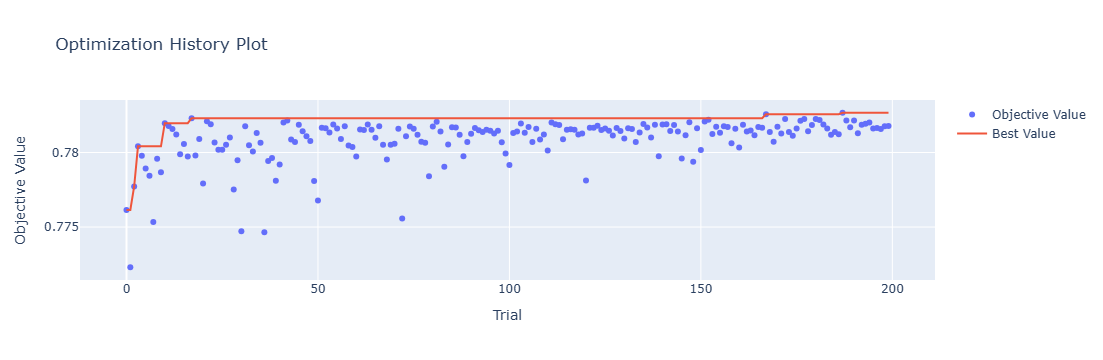

In [285]:
# Визуализация важности гиперпараметров (LightGBM)
optuna.visualization.plot_param_importances(study_lgb)
# Визуализация процесса оптимизации (как рос AUC)
optuna.visualization.plot_optimization_history(study_lgb)

![](newplot.png)

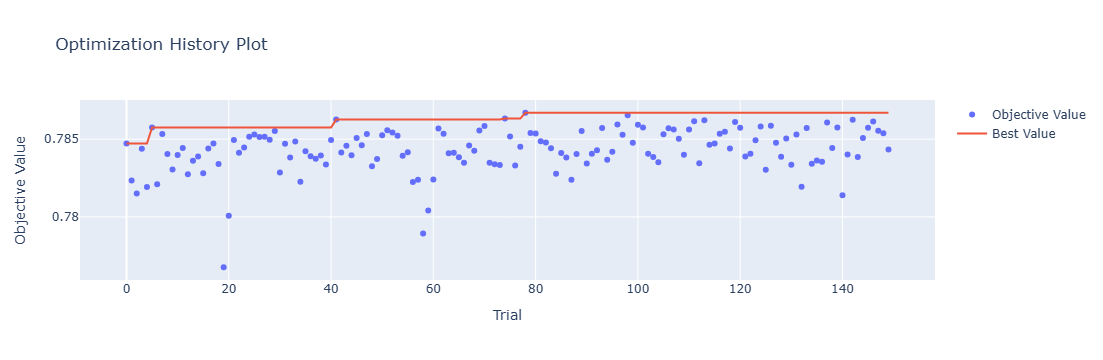

In [286]:
optuna.visualization.plot_param_importances(study_cb)
optuna.visualization.plot_optimization_history(study_cb)

![](newplot(1).png)

### Train

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### CatBoost

In [85]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.04,
    depth=4,
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    cat_features=['db_group_last'], 
    #nan_mode='Min',
    random_state=42,
    verbose=50,
    early_stopping_rounds=50,
    thread_count= -1,
)

# Обучение модели
model.fit(
    X, y,
    eval_set=(X_test, y_test),
    verbose_eval=50
)

0:	test: 0.7254686	best: 0.7254686 (0)	total: 70.6ms	remaining: 35.2s
50:	test: 0.7976094	best: 0.7976094 (50)	total: 3.48s	remaining: 30.6s
100:	test: 0.8091261	best: 0.8091261 (100)	total: 7.19s	remaining: 28.4s
150:	test: 0.8150699	best: 0.8150699 (150)	total: 10.7s	remaining: 24.7s
200:	test: 0.8189532	best: 0.8189532 (200)	total: 14.1s	remaining: 21s
250:	test: 0.8217745	best: 0.8217745 (250)	total: 17.6s	remaining: 17.4s
300:	test: 0.8244821	best: 0.8244821 (300)	total: 21.2s	remaining: 14s
350:	test: 0.8277570	best: 0.8277570 (350)	total: 24.8s	remaining: 10.5s
400:	test: 0.8305015	best: 0.8305015 (400)	total: 28.3s	remaining: 7s
450:	test: 0.8327793	best: 0.8327793 (450)	total: 31.9s	remaining: 3.47s
499:	test: 0.8346186	best: 0.8346186 (499)	total: 35.5s	remaining: 0us

bestTest = 0.8346185901
bestIteration = 499



In [81]:
# Предсказания
y_pred_proba = model.predict_proba(X_test)[:, 1]
#y_pred = (y_pred_proba > 0.5).astype(int)

print(f'Test roc_auc : {roc_auc_score(y_test, y_pred_proba)}')

y_pred_proba = model.predict_proba(X_train)[:, 1]
#y_pred = (y_pred_proba > 0.5).astype(int)

print(f'Train roc_auc : {roc_auc_score(y_train, y_pred_proba)}')

Test roc_auc : 0.8223217675211238
Train roc_auc : 0.8430019019968426


### LAMA

In [345]:
best_params_cb

{'depth': 4,
 'l2_leaf_reg': 12.456005584199426,
 'learning_rate': 0.07046118337487371,
 'bagging_temperature': 0.5929183831906306,
 'random_strength': 1.994282525245133,
 'thread_count': 16,
 'auto_class_weights': 'Balanced'}

In [359]:
del best_params_cb['depth']
best_params_cb['max_depth'] = 4
# del best_params_cb['bagging_temperature']

In [361]:
best_params_cb

{'l2_leaf_reg': 12.456005584199426,
 'learning_rate': 0.07046118337487371,
 'random_strength': 1.994282525245133,
 'thread_count': 16,
 'auto_class_weights': 'Balanced',
 'max_depth': 4}

In [333]:
train_df[['db_group_last','fl_adminarea']] = train_df[['db_group_last','fl_adminarea']].astype('object')

In [309]:
tscv = TimeSeriesSplit(n_splits=5)

In [445]:
task = Task('binary', metric='auc', greater_is_better=True)

roles = {
    'target': 'target_value',
    'drop': drop_list,  # ['front_id', 'decision_day']
    'category': ['db_group_last','fl_adminarea']
}

automl = TabularAutoML(
    task=task,
    timeout=7200,
    cpu_limit=16,
    reader_params={'n_jobs': 16, 
                   #'cv':tscv
                  },
    #cv_iter=tscv,
    general_params={
        'use_algos': [['linear_l2', 'lgb', 'cb', 'lgb_tuned', 'cb_tuned']
                      #, ['lgb_tuned', 'cb_tuned']
                     ],
        'fe_generator': 'basic',
        #'blending': 0.5
    },
    lgb_params={'default_params': best_params_lgb},
    cb_params={'default_params': best_params_cb},
    #verbose=2
)
oof_pred = automl.fit_predict(train_df, roles=roles, verbose=1)

[12:25:48] Stdout logging level is INFO.
[12:25:48] Task: binary

[12:25:48] Start automl preset with listed constraints:
[12:25:48] - time: 7200.00 seconds
[12:25:48] - CPU: 16 cores
[12:25:48] - memory: 16 GB

[12:25:48] Train data shape: (145241, 53)

[12:26:13] Layer 1 train process start. Time left 7175.15 secs
[12:26:19] Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
[12:26:38] Fitting Lvl_0_Pipe_0_Mod_0_LinearL2 finished. score = 0.8208438046136118
[12:26:38] Lvl_0_Pipe_0_Mod_0_LinearL2 fitting and predicting completed
[12:26:38] Time left 7150.69 secs

[12:26:40] Selector_LightGBM fitting and predicting completed
[12:26:48] Start fitting Lvl_0_Pipe_1_Mod_0_LightGBM ...
[12:27:08] Fitting Lvl_0_Pipe_1_Mod_0_LightGBM finished. score = 0.8308062237478281
[12:27:08] Lvl_0_Pipe_1_Mod_0_LightGBM fitting and predicting completed
[12:27:08] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ... Time budget is 300.00 secs


Optimization Progress:   0%|                                                                   | 0/101 [00:00<?, ?it/s][I 2026-06-18 12:27:08,544] A new study created in memory with name: no-name-892e630f-7ab9-4d25-88d9-d3b545585fba
[I 2026-06-18 12:27:13,073] Trial 0 finished with value: 0.8273930112834877 and parameters: {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}. Best is trial 0 with value: 0.8273930112834877.
Optimization Progress: 100%|████████████████████████| 101/101 [04:51<00:00,  2.88s/it, best_trial=76, best_value=0.833]

[12:31:59] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM completed
[12:31:59] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...


[12:32:45] Fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM finished. score = 0.834700611744972
[12:32:45] Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM fitting and predicting completed
[12:32:45] Start fitting Lvl_0_Pipe_1_Mod_2_CatBoost ...
[12:34:48] Fitting Lvl_0_Pipe_1_Mod_2_CatBoost finished. score = 0.8331625132504851
[12:34:48] Lvl_0_Pipe_1_Mod_2_CatBoost fitting and predicting completed
[12:34:48] Start hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ... Time budget is 300.00 secs


Optimization Progress:   0%|                                                                   | 0/101 [00:00<?, ?it/s][I 2026-06-18 12:34:48,349] A new study created in memory with name: no-name-e9d3b725-70d5-4826-8b9b-5775f0879758
[I 2026-06-18 12:35:01,402] Trial 0 finished with value: 0.8282751906797783 and parameters: {'max_depth': 4, 'nan_mode': 'Max', 'l2_leaf_reg': 0.0024430162614261413, 'min_data_in_leaf': 4}. Best is trial 0 with value: 0.8282751906797783.
Optimization Progress:  18%|████▋                     | 18/101 [05:22<24:48, 17.93s/it, best_trial=8, best_value=0.831]

[12:40:11] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost completed
[12:40:11] Start fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost ...


[12:41:40] Fitting Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost finished. score = 0.8314196503739252
[12:41:40] Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost fitting and predicting completed
[12:41:40] Time left 6247.78 secs

[12:41:40] Layer 1 training completed.

[12:41:40] Blending: optimization starts with equal weights. Score = 0.8354611
[12:41:42] Blending: iteration 0: score = 0.8356813, weights = [0.08670507 0.1122407  0.427541   0.2317618  0.14175148]
[12:41:43] Blending: iteration 1: score = 0.8356851, weights = [0.1244069  0.10302421 0.41107637 0.22557612 0.1359164 ]
[12:41:44] Blending: iteration 2: score = 0.8356861, weights = [0.12377308 0.09349389 0.41648462 0.22854388 0.13770455]
[12:41:46] Blending: no improvements for score. Terminated.

[12:41:46] Blending: best score = 0.8356861, best weights = [0.12377308 0.09349389 0.41648462 0.22854388 0.13770455]
[12:41:46] Automl preset training completed in 957.38 seconds

[12:41:46] Model description:
Final prediction for new objects (level 0) = 
	

<Axes: xlabel='Feature'>

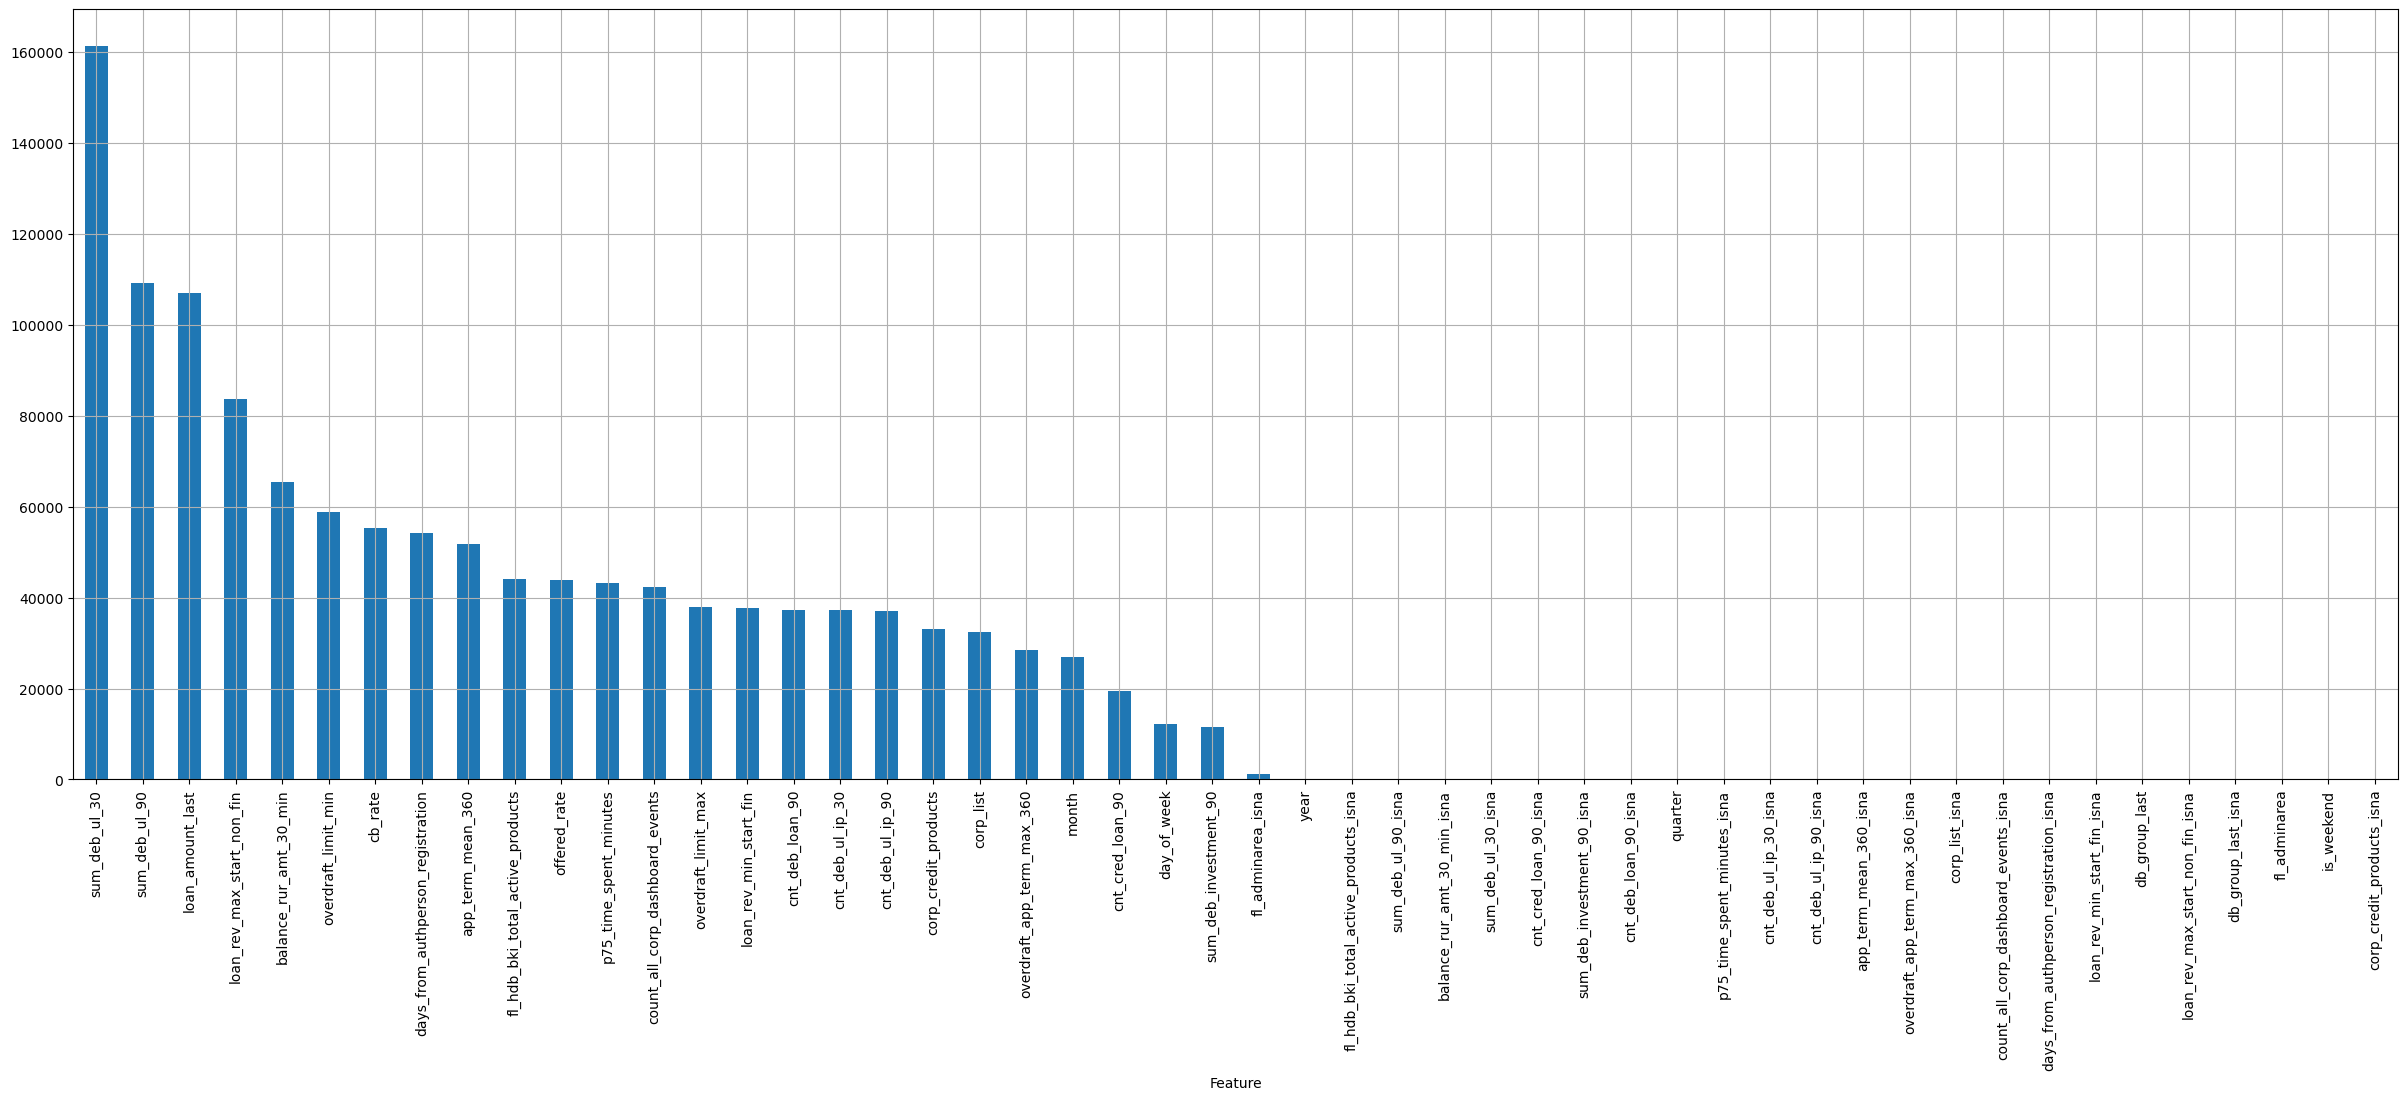

In [433]:
fast_fi = automl.get_feature_scores('fast')
fast_fi.set_index('Feature')['Importance'].plot.bar(figsize = (30, 10), grid = True)

In [443]:
drop_list = [col for col in fast_fi[27:]['Feature']] + ['front_id', 'decision_day']

In [130]:
# Предсказания
#y_pred_proba = model.predict_proba(X_test)[:, 1]
test_pred = automl.predict(X_test)
y_pred_proba = test_pred.data

print(f'Test roc_auc : {roc_auc_score(y_test, y_pred_proba)}')

#y_pred_proba = model.predict_proba(X_train)[:, 1]
test_pred = automl.predict(X_train)
y_pred_proba = test_pred.data

print(f'Train roc_auc : {roc_auc_score(y_train, y_pred_proba)}')

Test roc_auc : 0.892951578090576
Train roc_auc : 0.8968659550425774


### Test prep

In [365]:
test_df

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,count_all_corp_dashboard_events_isna,p75_time_spent_minutes_isna,sum_deb_investment_90_isna,db_group_last_isna,fl_adminarea_isna,day_of_week,month,quarter,year,is_weekend
0,150378,2025-06-05,0.000000,1.480173,1.038845,0.709770,1.602779,1.294844,0.079623,-2.472205,...,0,0,1,0,0,3,6,2,2025,0
1,194170,2025-06-05,0.961691,2.573324,1.901177,2.306751,1.602779,0.831485,NaN,NaN,...,0,0,1,1,0,3,6,2,2025,0
2,102106,2025-06-05,-0.623060,-3.719511,-3.062922,1.596982,1.602779,NaN,NaN,NaN,...,1,1,1,0,1,3,6,2,2025,0
3,256199,2025-06-05,0.000000,1.526705,1.075552,163.069565,1.602779,NaN,NaN,NaN,...,1,1,1,1,0,3,6,2,2025,0
4,253573,2025-06-05,2.185431,1.998064,1.447383,3.371406,1.602779,NaN,NaN,NaN,...,1,1,1,0,1,3,6,2,2025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36306,109998,2025-12-01,2.185431,-0.163767,2.884872,0.177442,-0.200347,NaN,NaN,NaN,...,1,1,1,1,1,0,12,4,2025,0
36307,258359,2025-12-01,1.690880,3.892473,2.941786,108.949633,-0.200347,0.000000,0.578975,1.475393,...,0,0,1,1,1,0,12,4,2025,0
36308,258402,2025-12-01,1.339991,1.444637,1.010812,2.484194,-0.200347,NaN,NaN,NaN,...,1,1,1,0,1,0,12,4,2025,0
36309,181981,2025-12-01,0.716931,3.906632,2.952955,0.177442,-0.200347,0.000000,-1.344113,-10.858433,...,0,0,0,1,1,0,12,4,2025,0


In [447]:
test_pred = automl.predict(test_df)

In [448]:
test_id = test_df['front_id']

In [451]:
res_df = pd.DataFrame(test_id)
res_df['target_value'] = test_pred.data[:,0]
res_df

,front_id,target_value
0,150378,0.341095
1,194170,0.140359
2,102106,0.066830
3,256199,0.424082
4,253573,0.230634
...,...,...
36306,109998,0.152814
36307,258359,0.565563
36308,258402,0.197751
36309,181981,0.195895


In [425]:
res_df = pd.DataFrame(test_id)
res_df['target_value'] = test_pred.data[:,0]
res_df

,front_id,target_value
0,150378,0.347399
1,194170,0.142283
2,102106,0.067825
3,256199,0.432616
4,253573,0.235368
...,...,...
36306,109998,0.156073
36307,258359,0.575576
36308,258402,0.201569
36309,181981,0.199089


In [453]:
res_df.to_csv('sample_submission_try_11_lama.csv', index=False)

### CatBoost predict

In [367]:
y_pred_proba = model.predict_proba(test_df)[:, 1]

NameError: name 'model' is not defined

In [89]:
len(y_pred_proba)

36311

In [91]:
test_df_0 = pd.read_csv('test_apps.csv')

In [97]:
test_id = test_df_0['front_id']

In [99]:
res_df = pd.DataFrame(test_id)
res_df['target_value'] = y_pred_proba
res_df

,front_id,target_value
0,150378,0.526318
1,194170,0.411293
2,102106,0.157516
3,256199,0.290054
4,253573,0.341158
...,...,...
36306,109998,0.136604
36307,258359,0.270234
36308,258402,0.117171
36309,181981,0.234497


In [183]:
res_df = pd.DataFrame(test_id)
res_df['target_value'] = y_pred_proba
res_df

,front_id,target_value
0,150378,0.557717
1,194170,0.274352
2,102106,0.126873
3,256199,0.304350
4,253573,0.358485
...,...,...
36306,109998,0.124774
36307,258359,0.150301
36308,258402,0.085189
36309,181981,0.251904


In [101]:
res_df.to_csv('sample_submission_try_8_cb.csv', index=False)

### LAMA predict

In [187]:
test_pred = automl.predict(X)
y_proba = test_pred.data

In [189]:
predicts = y_proba.reshape(1,-1)[0]

In [191]:
res_df = pd.DataFrame(test_id)
res_df['target_value'] = predicts
res_df

,front_id,target_value
0,150378,0.066285
1,194170,0.025043
2,102106,0.008344
3,256199,0.047500
4,253573,0.024346
...,...,...
36306,109998,0.016859
36307,258359,0.083205
36308,258402,0.015775
36309,181981,0.024687


In [193]:
res_df.to_csv('sample_submission_try_7_lama.csv', index=False)